In [6]:
import numpy as np 
import matplotlib.pyplot as plt
from hamiltonian_matrix import hamiltonian_matrix


In [35]:
# Infinite Potential Well
def infinite_well(L, interior_points, state_number):
    """ Solving particle in a box problem in 1-D
        L : width of the box
        interior_points : the number of grid points inside the wall
        state_number : quantum state to plot; starts from 0
    """
    
    if interior_points <= 0:
        raise ValueError("interior_points must be positive.")

    if state_number < 0 or state_number >= interior_points:
        raise ValueError("Invalid state_number.")
    
    
    dx = L/(interior_points+1)
    x_full = np.linspace(0, L, interior_points + 2)
    
    # Infinite well:  V = 0  inside the walls
    potential_values = np.zeros(interior_points)
    
    hamiltonian = hamiltonian_matrix(interior_points, dx, potential_values)
    
    energies, wavefunctions = np.linalg.eigh(hamiltonian)
    quantum_number = np.arange(1, len(energies)+1)
    analytical_energies = quantum_number**2 * np.pi**2 / (2 * L**2)
    
    # Adding the end points
    phi = np.concatenate(([0], wavefunctions[:, state_number], [0]))
    
    # Normalization of the wavefunction
    norm = np.sum(np.abs(phi)**2)*dx
    phi_norm = phi / np.sqrt(norm)
    
    # Probability density of normalised wavefunction
    probability_density = np.abs(phi_norm)**2
    area = np.trapz(probability_density, dx=dx)
    return x_full, phi_norm, energies, probability_density, area, quantum_number, analytical_energies

plotting wavefunctions for different states (n):

In [36]:
L = 2
interior_points = 1000
state_number = 0
x_full , phi_norm,energies, probability_density, area, quantum_number, analytical_energies = infinite_well(L,interior_points, state_number)

C:\Users\hp\AppData\Local\Temp\ipykernel_7424\1495374939.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(probability_density, dx=dx)


C:\Users\hp\AppData\Local\Temp\ipykernel_7424\1495374939.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(probability_density, dx=dx)


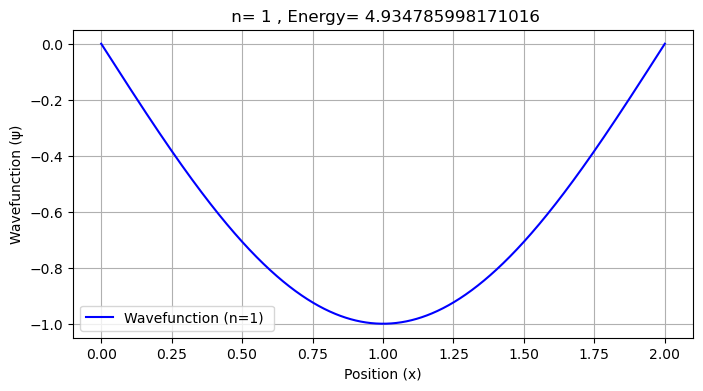

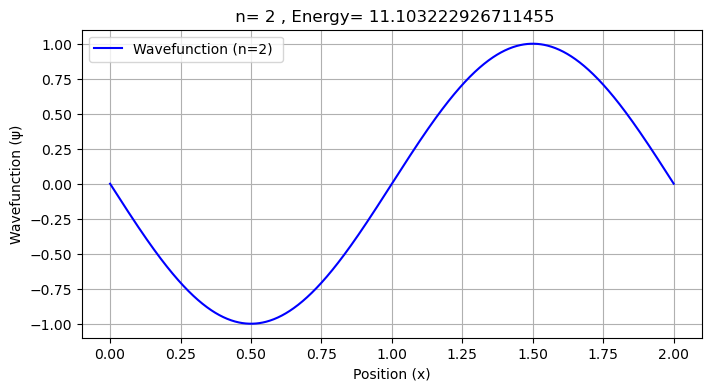

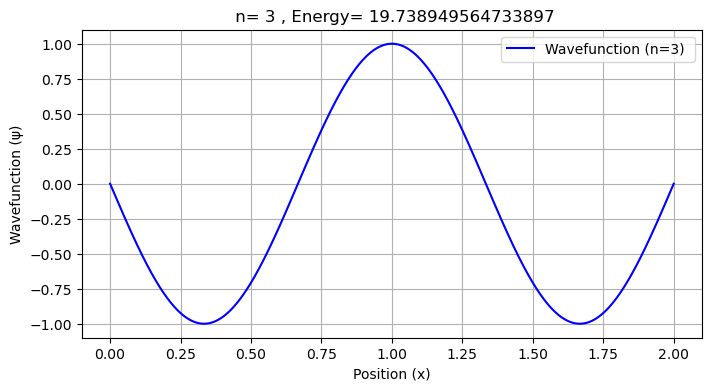

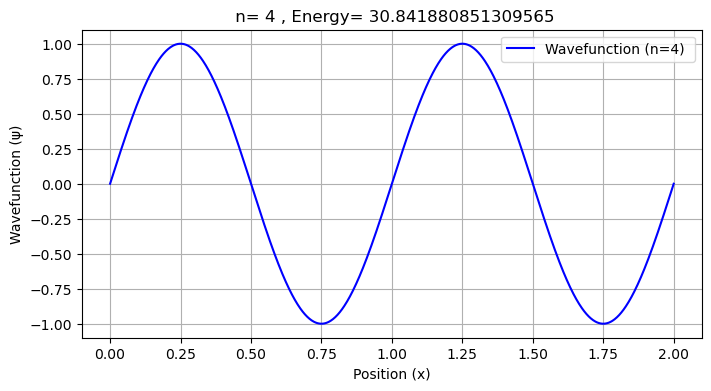

In [38]:
L = 2
interior_points = 1000
for i in range(4):
    state_number = i
    x_full , phi_norm,energies, probability_density, area, quantum_number, analytical_energies = infinite_well(L,interior_points, state_number)
    
    plt.figure(figsize=(8,4))
    plt.plot(x_full, phi_norm, label=f'Wavefunction (n={state_number+1}) ' , color='blue')
    plt.title(f' n= {state_number+1} , Energy= {energies[state_number+1]}')
    plt.xlabel('Position (x)')
    plt.ylabel('Wavefunction (ψ)')
    plt.legend()
    plt.grid(True)
    plt.show()


In [39]:
L = 2
interior_points = 1000
state_number = 0
x_full , phi_norm,energies, probability_density, area, quantum_number, analytical_energies = infinite_well(L,interior_points, state_number)

C:\Users\hp\AppData\Local\Temp\ipykernel_7424\1495374939.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(probability_density, dx=dx)


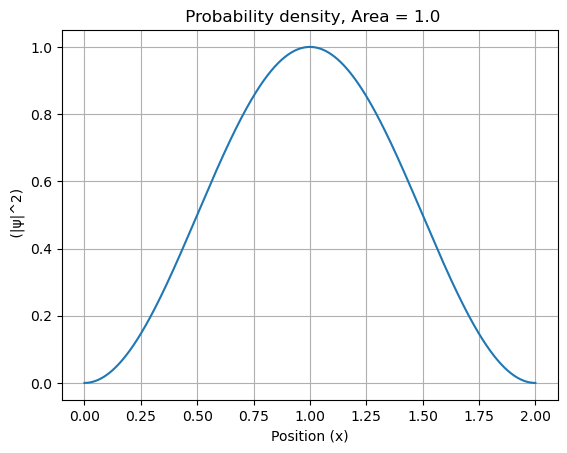

In [41]:

# plotting the probability density 
plt.plot(x_full, probability_density)
plt.title(f' Probability density, Area = {area}')
plt.xlabel('Position (x)')
plt.ylabel(' (|ψ|^2)')
plt.grid(True)
plt.show()

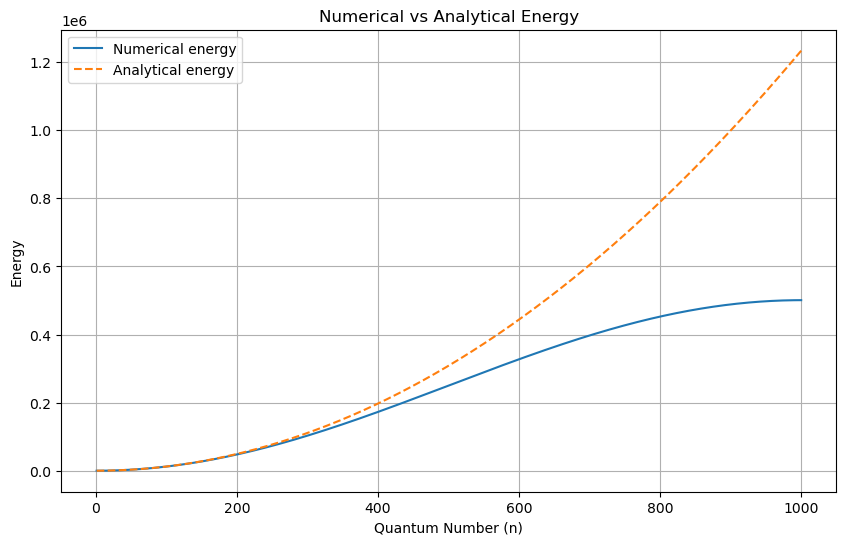

In [42]:
# plotting the energy vs quantum number graph
plt.figure(figsize=(10, 6))
plt.plot(quantum_number,energies,label="Numerical energy")
plt.plot(quantum_number,analytical_energies,label="Analytical energy", linestyle = '--' )
plt.xlabel("Quantum Number (n)")
plt.ylabel("Energy")
plt.title("Numerical vs Analytical Energy")
plt.legend()
plt.grid(True)
plt.show()